# Chapter 6 - Linear Model Selection and Regularization

- [Lab 2: Ridge Regression](#6.6.1-Ridge-Regression)
- [Lab 2: The Lasso](#6.6.2-The-Lasso)
- [Lab 3: Principal Components Regression](#6.7.1-Principal-Components-Regression)
- [Lab 3: Partial Least Squares](#6.7.2-Partial-Least-Squares)

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
%matplotlib inline
plt.style.use('seaborn-v0_8-white')

In [92]:
df = pd.read_csv('Data/Hitters.csv', index_col=0).dropna()
df.index.name = 'Player'
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
Player,,,,,,,,,,,,,,,,,,,,
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [93]:
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])
#dummies.info()
print(dummies.head())

                   League_A  League_N  Division_E  Division_W  NewLeague_A  \
Player                                                                       
-Alan Ashby           False      True       False        True        False   
-Alvin Davis           True     False       False        True         True   
-Andre Dawson         False      True        True       False        False   
-Andres Galarraga     False      True        True       False        False   
-Alfredo Griffin       True     False       False        True         True   

                   NewLeague_N  
Player                          
-Alan Ashby               True  
-Alvin Davis             False  
-Andre Dawson             True  
-Andres Galarraga         True  
-Alfredo Griffin         False  


In [94]:
y = df.Salary
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
Player,,,,,,,,,,,,,,,,,,,
-Alan Ashby,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,True,True,True
-Alvin Davis,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,False,True,False
-Andre Dawson,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,True,False,True
-Andres Galarraga,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,True,False,True
-Alfredo Griffin,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,False,True,False


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
list_numerical=X_train.columns[:16]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train[list_numerical]) 
X_train[list_numerical] = scaler.transform(X_train[list_numerical])
X_test[list_numerical] = scaler.transform(X_test[list_numerical])

In [97]:
reg = Lasso(alpha=1)
reg.fit(X_train, y_train)
print('R squared training set', round(reg.score(X_train, y_train)*100, 2))
print('R squared test set', round(reg.score(X_test, y_test)*100, 2))

R squared training set 58.62
R squared test set 30.22


In [98]:
# Training data
pred_train = reg.predict(X_train)
mse_train = mean_squared_error(y_train, pred_train)
print('MSE training set', round(mse_train, 2))

# Test data
pred = reg.predict(X_test)
mse_test =mean_squared_error(y_test, pred)
print('MSE test set', round(mse_test, 2))

MSE training set 86053.51
MSE test set 126212.38


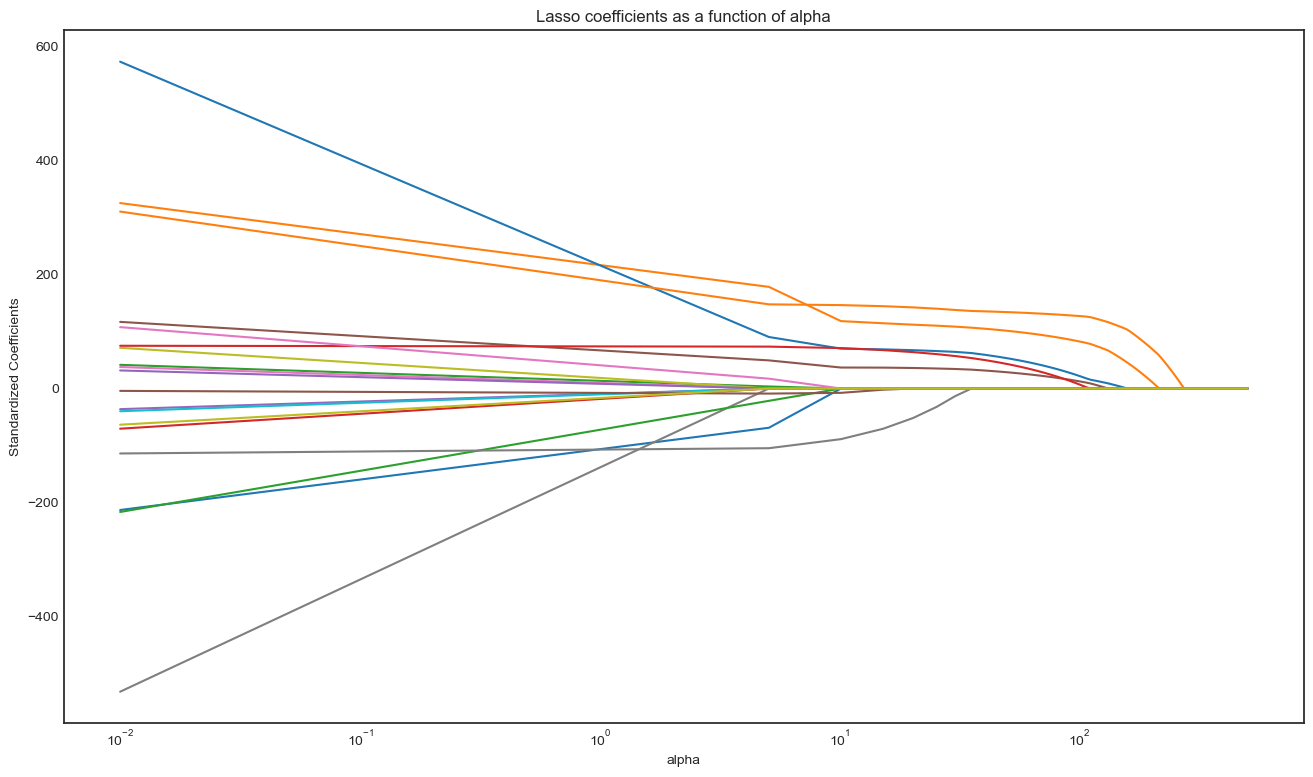

In [99]:
alphas = np.linspace(0.01,500,100)
lasso = Lasso(max_iter=10000)
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

plt.figure(figsize=(16,9))
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients as a function of alpha')
plt.show()

In [100]:
model = LassoCV(cv=5, random_state=0, max_iter=10000)
model.fit(X_train, y_train)
model.alpha_

10.250469583914377

In [101]:
lasso_best = Lasso(alpha=model.alpha_)
lasso_best.fit(X_train, y_train)
print('R squared training set', round(lasso_best.score(X_train, y_train)*100, 2))
print('R squared test set', round(lasso_best.score(X_test, y_test)*100, 2))

R squared training set 54.5
R squared test set 19.8


In [102]:
print('mean squared error training set:', mean_squared_error(y_train, lasso_best.predict(X_train)))
print('mean squared error test set:', mean_squared_error(y_test, lasso_best.predict(X_test)))

mean squared error training set: 94613.03119763568
mean squared error test set: 145067.03639338588


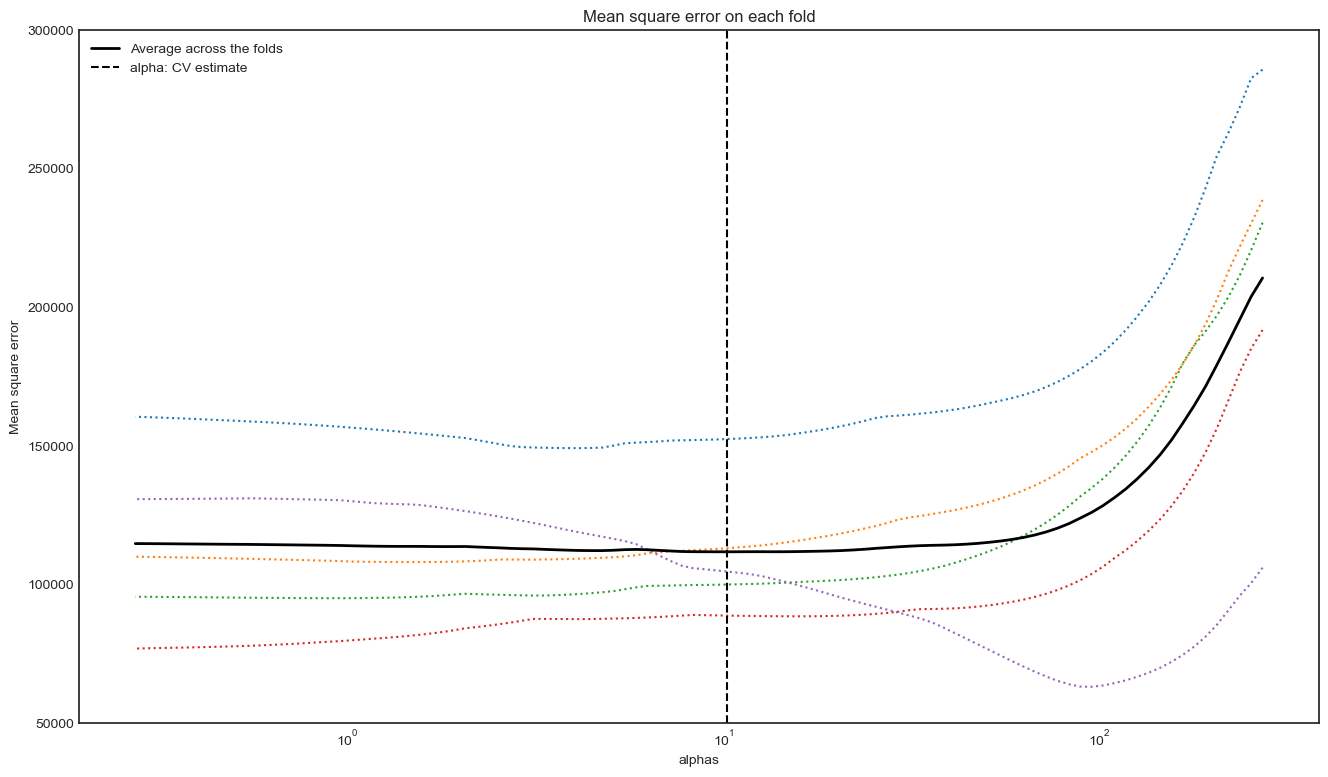

In [103]:
plt.figure(figsize=(16,9))
plt.semilogx(model.alphas_, model.mse_path_, ":")
plt.plot(
    model.alphas_ ,
    model.mse_path_.mean(axis=-1),"k",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(model.alpha_, linestyle="--", color="k", label="alpha: CV estimate")
plt.legend()
plt.xlabel("alphas")
plt.ylabel("Mean square error")
plt.title("Mean square error on each fold")
plt.axis("tight")
ymin, ymax = 50000, 300000
plt.ylim(ymin, ymax);
plt.show()

# Ridge

In [104]:
from sklearn.linear_model import RidgeCV,Ridge

In [105]:
reg = Ridge(alpha=1)
reg.fit(X_train, y_train)
print('R squared training set', round(reg.score(X_train, y_train)*100, 2))
print('R squared test set', round(reg.score(X_test, y_test)*100, 2))

R squared training set 58.6
R squared test set 30.03


In [106]:
from sklearn.metrics import mean_squared_error

# Training data
pred_train = reg.predict(X_train)
mse_train = mean_squared_error(y_train, pred_train)
print('MSE training set', round(mse_train, 2))

# Test data
pred = reg.predict(X_test)
mse_test =mean_squared_error(y_test, pred)
print('MSE test set', round(mse_test, 2))

MSE training set 86103.31
MSE test set 126551.99


In [107]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(0.01,500,100)
ridge= Ridge()
coefs = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_[0])

ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients as a function of alpha')

Text(0.5, 1.0, 'Lasso coefficients as a function of alpha')

In [108]:
from sklearn.linear_model import RidgeCV

# Lasso with 5 fold cross-validation
model = RidgeCV(cv=5,alphas=alphas,scoring='r2')

# Fit model
model.fit(X_train, y_train)

RidgeCV(alphas=array([1.00000000e-02, 5.06040404e+00, 1.01108081e+01, 1.51612121e+01,
       2.02116162e+01, 2.52620202e+01, 3.03124242e+01, 3.53628283e+01,
       4.04132323e+01, 4.54636364e+01, 5.05140404e+01, 5.55644444e+01,
       6.06148485e+01, 6.56652525e+01, 7.07156566e+01, 7.57660606e+01,
       8.08164646e+01, 8.58668687e+01, 9.09172727e+01, 9.59676768e+01,
       1.01018081e+02, 1.06068485e+0...
       3.83840707e+02, 3.88891111e+02, 3.93941515e+02, 3.98991919e+02,
       4.04042323e+02, 4.09092727e+02, 4.14143131e+02, 4.19193535e+02,
       4.24243939e+02, 4.29294343e+02, 4.34344747e+02, 4.39395152e+02,
       4.44445556e+02, 4.49495960e+02, 4.54546364e+02, 4.59596768e+02,
       4.64647172e+02, 4.69697576e+02, 4.74747980e+02, 4.79798384e+02,
       4.84848788e+02, 4.89899192e+02, 4.94949596e+02, 5.00000000e+02]),
        cv=5, scoring='r2')

In [109]:
model.alpha_

131.32050505050503

In [110]:
ridge_best = Ridge(alpha=model.alpha_)
ridge_best.fit(X_train, y_train)
print('R squared training set', round(ridge_best.score(X_train, y_train)*100, 2))
print('R squared test set', round(ridge_best.score(X_test, y_test)*100, 2))

R squared training set 51.92
R squared test set 17.71


In [111]:
mean_squared_error(y_test, ridge_best.predict(X_test))

148839.51605103014

In [112]:
mse = []
# 1. Duyệt qua từng alpha trong RidgeCV dùng model.alphas (không có `_`)
for a in model.alphas:
    # 2. Khởi tạo và fit mô hình Ridge tương ứng với alpha = a
    ridge_a = Ridge(alpha=a)
    ridge_a.fit(X_train, y_train)
    
    # 3. Dự báo trên tập X_test
    pred = ridge_a.predict(X_test)
    
    # 4. Tính MSE
    mse.append(mean_squared_error(y_test, pred))


In [113]:
from sklearn.linear_model import RidgeCV, Lasso, LassoCV

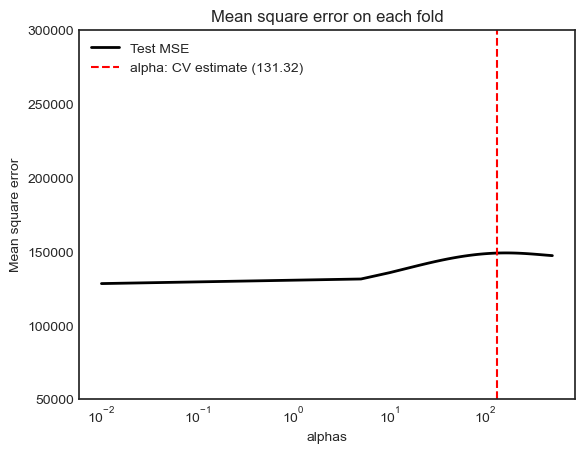

In [114]:
# plt.semilogx(model.alphas,model.r2_path_)
# plt.plot(
#     model.alphas ,
#     mse.mean(axis=-1),"k",
#     label="Average across the folds",
#     linewidth=2,
# )
# 1. Vẽ đồ thị MSE theo danh sách alphas (trục X dạng log)
plt.semilogx(model.alphas, mse, "k-", label="Test MSE", linewidth=2)

# 2. Vẽ đường vạch nét đứt tại alpha tối ưu
plt.axvline(
    model.alpha_, linestyle="--", color="r", label=f"alpha: CV estimate ({model.alpha_:.2f})"
)

plt.legend()
plt.xlabel("alphas")
plt.ylabel("Mean square error")
plt.title("Mean square error on each fold")
plt.axis("tight")

ymin, ymax = 50000, 300000
plt.ylim(ymin, ymax)
plt.show()

In [115]:
model.score(X_test,y_test)

0.17710034746320724

### 6.6.1 Ridge Regression

### Scikit-learn

The __glmnet__ algorithms in R optimize the objective function using cyclical coordinate descent, while scikit-learn Ridge regression uses linear least squares with L2 regularization. They are rather different implementations, but the general principles are the same.

The __glmnet() function in R__ optimizes:
### $$ \frac{1}{N}|| X\beta-y||^2_2+\lambda\bigg(\frac{1}{2}(1−\alpha)||\beta||^2_2 \ +\ \alpha||\beta||_1\bigg) $$
(See R documentation and https://cran.r-project.org/web/packages/glmnet/vignettes/glmnet_beta.pdf)<BR>
The function supports L1 and L2 regularization. For just Ridge regression we need to use $\alpha = 0 $. This reduces the above cost function to
### $$ \frac{1}{N}|| X\beta-y||^2_2+\frac{1}{2}\lambda ||\beta||^2_2 $$
The __sklearn Ridge()__ function optimizes:
### $$ ||X\beta - y||^2_2 + \alpha ||\beta||^2_2 $$
which is equivalent to optimizing
### $$ \frac{1}{N}||X\beta - y||^2_2 + \frac{\alpha}{N} ||\beta||^2_2 $$

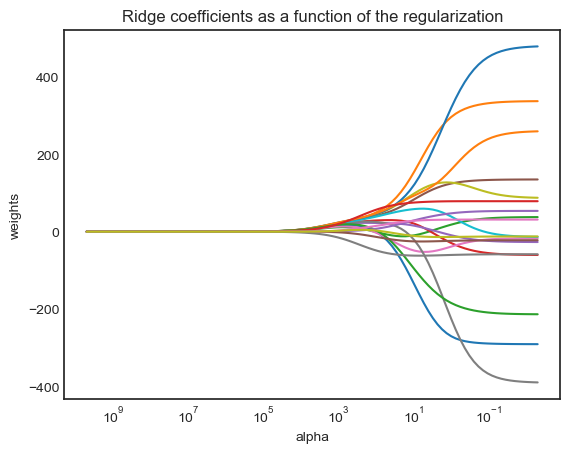

In [116]:
# 1. Import đúng hàm scale từ sklearn
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import numpy as np

alphas = 10**np.linspace(10, -2, 100) * 0.5

ridge = Ridge()
coefs = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(scale(X), y)  # Đã hoạt động chính xác
    coefs.append(ridge.coef_)

# 2. Vẽ đồ thị
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])  # Đảo ngược chiều trục X
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.show()


The above plot shows that the Ridge coefficients get larger when we decrease alpha.

#### Alpha = 4

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)

In [118]:
ridge2 = Ridge(alpha=len(X_)*11498/2)
ridge2.fit(scaler.transform(X_train), y_train)
pred = ridge2.predict(scaler.transform(X_test))
mean_squared_error(y_test, pred)

182234.34594897428

In [119]:
pd.Series(ridge2.coef_.flatten(), index=X.columns)

AtBat          0.029004
Hits           0.031708
HmRun          0.024915
Runs           0.029767
RBI            0.031617
Walks          0.029162
Years          0.027738
CAtBat         0.035229
CHits          0.036371
CHmRun         0.034535
CRuns          0.037047
CRBI           0.037775
CWalks         0.032776
PutOuts        0.021366
Assists        0.002076
Errors         0.000889
League_N      -0.000480
Division_W    -0.012208
NewLeague_N    0.000422
dtype: float64

#### Alpha = $10^{10}$ 
This big penalty shrinks the coefficients to a very large degree and makes the model more biased, resulting in a higher MSE.

In [120]:
ridge2.set_params(alpha=10**10)
ridge2.fit(scale(X_train), y_train)
pred = ridge2.predict(scale(X_test))
mean_squared_error(y_test, pred)

182346.6834715712

#### Compute the regularization path using RidgeCV

In [121]:
ridgecv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
ridgecv.fit(scale(X_train), y_train)

RidgeCV(alphas=array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501e+07, 3.28966612e+07, 2.48851178e+07,
       1.88246790e+07, 1.42401793e+0...
       3.06795364e+00, 2.32079442e+00, 1.75559587e+00, 1.32804389e+00,
       1.00461650e+00, 7.59955541e-01, 5.74878498e-01, 4.34874501e-01,
       3.28966612e-01, 2.48851178e-01, 1.88246790e-01, 1.42401793e-01,
       1.07721735e-01, 8.14875417e-02, 6.16423370e-02, 4.66301673e-02,
       3.52740116e-02, 2.66834962e-02, 2.01850863e-02, 1.52692775e-02,
       1.15506485e-02, 8.73764200e-03, 6.60970574e-03, 5.00000000e-03]),
        scoring='neg_mean_squared_error')

In [122]:
ridgecv.alpha_

115.5064850041579

In [123]:
ridge2.set_params(alpha=ridgecv.alpha_)
ridge2.fit(scale(X_train), y_train)
mean_squared_error(y_test, ridge2.predict(scale(X_test)))

150039.23724262207

In [124]:
pd.Series(ridge2.coef_.flatten(), index=X.columns)

AtBat          18.607335
Hits           51.392848
HmRun           9.381874
Runs           29.738483
RBI            24.482229
Walks          31.224022
Years          14.767558
CAtBat         28.129486
CHits          40.180804
CHmRun         30.932184
CRuns          38.577448
CRBI           41.437504
CWalks         12.018662
PutOuts        54.086742
Assists        -0.396203
Errors         -8.732521
League_N       13.365662
Division_W    -41.926945
NewLeague_N     2.660610
dtype: float64

### python-glmnet (update 2016-08-29)
This relatively new module is a wrapper for the fortran library used in the R package `glmnet`. It gives mostly the exact same results as described in the book. However, the `predict()` method does not give you the regression *coefficients* for lambda values not in the lambda_path. It only returns the predicted values.
https://github.com/civisanalytics/python-glmnet

In [ ]:
from glmnet import LogitNet # type: ignore
import glmnet as gln  # type: ignore


In [126]:
import warnings
warnings.filterwarnings('ignore')

In [56]:
grid = 10**np.linspace(10,-2,100)

ridge3 = gln.ElasticNet(alpha=0, lambda_path=grid)
ridge3.fit(X, y)

ElasticNet(alpha=0,
           lambda_path=array([1.00000000e+10, 7.56463328e+09, 5.72236766e+09, 4.32876128e+09,
       3.27454916e+09, 2.47707636e+09, 1.87381742e+09, 1.41747416e+09,
       1.07226722e+09, 8.11130831e+08, 6.13590727e+08, 4.64158883e+08,
       3.51119173e+08, 2.65608778e+08, 2.00923300e+08, 1.51991108e+08,
       1.14975700e+08, 8.69749003e+07, 6.57933225e+07, 4.97702356e+07,
       3.76493581e+...
       6.13590727e+00, 4.64158883e+00, 3.51119173e+00, 2.65608778e+00,
       2.00923300e+00, 1.51991108e+00, 1.14975700e+00, 8.69749003e-01,
       6.57933225e-01, 4.97702356e-01, 3.76493581e-01, 2.84803587e-01,
       2.15443469e-01, 1.62975083e-01, 1.23284674e-01, 9.32603347e-02,
       7.05480231e-02, 5.33669923e-02, 4.03701726e-02, 3.05385551e-02,
       2.31012970e-02, 1.74752840e-02, 1.32194115e-02, 1.00000000e-02]))

#### Lambda 11498

In [127]:
ridge3.lambda_path_[49]

11497.569953977356

In [128]:
print('Intercept: {:.3f}'.format(ridge3.intercept_path_[49]))

Intercept: 407.356


In [129]:
pd.Series(np.round(ridge3.coef_path_[:,49], decimals=3), index=X.columns)

AtBat          0.037
Hits           0.138
HmRun          0.525
Runs           0.231
RBI            0.240
Walks          0.290
Years          1.108
CAtBat         0.003
CHits          0.012
CHmRun         0.088
CRuns          0.023
CRBI           0.024
CWalks         0.025
PutOuts        0.016
Assists        0.003
Errors        -0.021
League_N       0.085
Division_W    -6.215
NewLeague_N    0.301
dtype: float64

In [130]:
np.sqrt(np.sum(ridge3.coef_path_[:,49]**2))

6.360612286538449

#### Lambda 705

In [131]:
ridge3.lambda_path_[59]

705.4802310718645

In [132]:
print('Intercept: {:.3f}'.format(ridge3.intercept_path_[59]))

Intercept: 54.325


In [133]:
pd.Series(np.round(ridge3.coef_path_[:,59], decimals=3), index=X.columns)

AtBat           0.112
Hits            0.656
HmRun           1.180
Runs            0.938
RBI             0.847
Walks           1.320
Years           2.596
CAtBat          0.011
CHits           0.047
CHmRun          0.338
CRuns           0.094
CRBI            0.098
CWalks          0.072
PutOuts         0.119
Assists         0.016
Errors         -0.704
League_N       13.684
Division_W    -54.659
NewLeague_N     8.612
dtype: float64

In [134]:
np.sqrt(np.sum(ridge3.coef_path_[:,59]**2))

57.110034367024085

#### Fit model using just the training set.

In [135]:
ridge4 = gln.ElasticNet(alpha=0, lambda_path=grid, scoring='mean_squared_error', tol=1e-12)
ridge4.fit(X_train, y_train.values.ravel())

ElasticNet(alpha=0,
           lambda_path=array([1.00000000e+10, 7.56463328e+09, 5.72236766e+09, 4.32876128e+09,
       3.27454916e+09, 2.47707636e+09, 1.87381742e+09, 1.41747416e+09,
       1.07226722e+09, 8.11130831e+08, 6.13590727e+08, 4.64158883e+08,
       3.51119173e+08, 2.65608778e+08, 2.00923300e+08, 1.51991108e+08,
       1.14975700e+08, 8.69749003e+07, 6.57933225e+07, 4.97702356e+07,
       3.76493581e+...
       6.13590727e+00, 4.64158883e+00, 3.51119173e+00, 2.65608778e+00,
       2.00923300e+00, 1.51991108e+00, 1.14975700e+00, 8.69749003e-01,
       6.57933225e-01, 4.97702356e-01, 3.76493581e-01, 2.84803587e-01,
       2.15443469e-01, 1.62975083e-01, 1.23284674e-01, 9.32603347e-02,
       7.05480231e-02, 5.33669923e-02, 4.03701726e-02, 3.05385551e-02,
       2.31012970e-02, 1.74752840e-02, 1.32194115e-02, 1.00000000e-02]),
           scoring='mean_squared_error', tol=1e-12)

In [136]:
# prediction using lambda = 4
pred = ridge4.predict(X_test, lamb=4)
mean_squared_error(y_test.values.ravel(), pred)

127619.11200193093

#### Lambda chosen by cross validation

In [137]:
ridge5 = gln.ElasticNet(alpha=0, scoring='mean_squared_error')
ridge5.fit(X_train, y_train.values.ravel())

ElasticNet(alpha=0, scoring='mean_squared_error')

In [138]:
# Lambda with best CV performance
ridge5.lambda_max_

534.4603336641825

In [139]:
# Lambda larger than lambda_max_, but with a CV score that is within 1 standard deviation away from lambda_max_ 
ridge5.lambda_best_

array([1632.16463421])

In [140]:
plt.figure(figsize=(15,6))
plt.errorbar(np.log(ridge5.lambda_path_), -ridge5.cv_mean_score_, color='r', linestyle='None', marker='o',
             markersize=5, yerr=ridge5.cv_standard_error_, ecolor='lightgrey', capsize=4)

for ref, txt in zip([ridge5.lambda_best_, ridge5.lambda_max_], ['Lambda best', 'Lambda max']):
    plt.axvline(x=np.log(ref), linestyle='dashed', color='lightgrey')
    plt.text(np.log(ref), .95*plt.gca().get_ylim()[1], txt, ha='center')

plt.xlabel('log(Lambda)')
plt.ylabel('Mean-Squared Error');

In [141]:
# MSE for lambda with best CV performance
pred = ridge5.predict(X_test, lamb=ridge5.lambda_max_)
mean_squared_error(y_test, pred)

146399.11866454475

#### Fit model to full data set

In [142]:
ridge6= gln.ElasticNet(alpha=0, scoring='mean_squared_error', n_splits=10)
ridge6.fit(X, y)

ElasticNet(alpha=0, n_splits=10, scoring='mean_squared_error')

In [143]:
# These are not really close to the ones in the book.
pd.Series(ridge6.coef_path_[:,ridge6.lambda_max_inx_], index=X.columns)

AtBat           0.046341
Hits            0.963770
HmRun           0.271637
Runs            1.101172
RBI             0.876057
Walks           1.753306
Years           0.504561
CAtBat          0.011249
CHits           0.062741
CHmRun          0.438964
CRuns           0.124712
CRBI            0.132539
CWalks          0.036730
PutOuts         0.184839
Assists         0.038470
Errors         -1.684718
League_N       25.757768
Division_W    -88.360620
NewLeague_N     7.916883
dtype: float64

### 6.6.2 The Lasso

### Scikit-learn



For both __glmnet__ in R and sklearn __Lasso()__ function the standard L1 penalty is:
### $$ \lambda |\beta|_1 $$

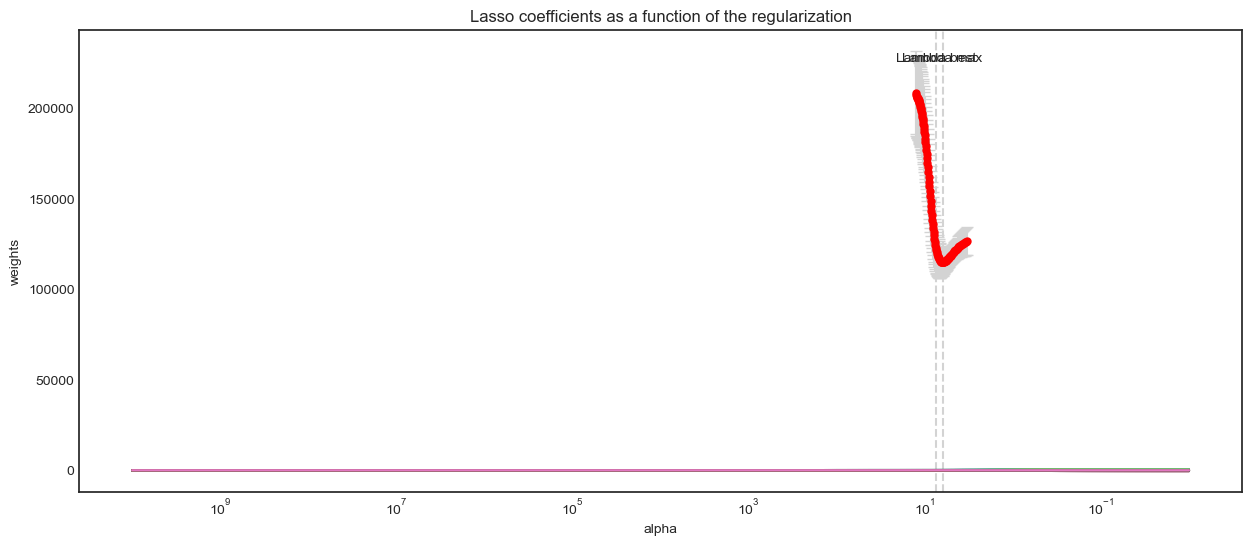

In [147]:
lasso = Lasso(max_iter=10000)
coefs = []

for a in alphas*2:
    lasso.set_params(alpha=a)
    lasso.fit(scale(X_train), y_train)
    coefs.append(lasso.coef_)

ax = plt.gca()
ax.plot(alphas*2, coefs)
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Lasso coefficients as a function of the regularization')
plt.show()

In [145]:
lassocv = LassoCV(alphas=None, cv=10, max_iter=10000)
lassocv.fit(scale(X_train), y_train.values.ravel())

LassoCV(cv=10, max_iter=10000)

In [148]:
lassocv.alpha_

1.6705711359637976

In [149]:
lasso.set_params(alpha=lassocv.alpha_)
lasso.fit(scale(X_train), y_train)
mean_squared_error(y_test, lasso.predict(scale(X_test)))

134088.63182639217

In [150]:
# Some of the coefficients are now reduced to exactly zero.
pd.Series(lasso.coef_, index=X.columns)

AtBat         -196.099730
Hits           269.450487
HmRun            7.121689
Runs            -8.181793
RBI              0.000000
Walks           89.448118
Years           -0.000000
CAtBat        -107.384284
CHits            0.000000
CHmRun          22.070451
CRuns          289.488217
CRBI           154.542217
CWalks        -147.619722
PutOuts         76.308184
Assists         12.332074
Errors          -5.283855
League_N        34.429333
Division_W     -57.284424
NewLeague_N    -15.294058
dtype: float64

### python-glmnet

In [151]:
lasso2 = gln.ElasticNet(alpha=1, lambda_path=grid, scoring='mean_squared_error', n_splits=10)
lasso2.fit(X_train, y_train.values.ravel())

ElasticNet(lambda_path=array([1.00000000e+10, 7.56463328e+09, 5.72236766e+09, 4.32876128e+09,
       3.27454916e+09, 2.47707636e+09, 1.87381742e+09, 1.41747416e+09,
       1.07226722e+09, 8.11130831e+08, 6.13590727e+08, 4.64158883e+08,
       3.51119173e+08, 2.65608778e+08, 2.00923300e+08, 1.51991108e+08,
       1.14975700e+08, 8.69749003e+07, 6.57933225e+07, 4.97702356e+07,
       3.76493581e+07, 2.848...
       6.13590727e+00, 4.64158883e+00, 3.51119173e+00, 2.65608778e+00,
       2.00923300e+00, 1.51991108e+00, 1.14975700e+00, 8.69749003e-01,
       6.57933225e-01, 4.97702356e-01, 3.76493581e-01, 2.84803587e-01,
       2.15443469e-01, 1.62975083e-01, 1.23284674e-01, 9.32603347e-02,
       7.05480231e-02, 5.33669923e-02, 4.03701726e-02, 3.05385551e-02,
       2.31012970e-02, 1.74752840e-02, 1.32194115e-02, 1.00000000e-02]),
           n_splits=10, scoring='mean_squared_error')

In [152]:
l1_norm = np.sum(np.abs(lasso2.coef_path_), axis=0)

plt.figure(figsize=(10,6))
plt.plot(l1_norm, lasso2.coef_path_.T)
plt.xlabel('L1 norm')
plt.ylabel('Coefficients');

#### Let glmnet() create a grid to use in CV

In [153]:
lasso3 = gln.ElasticNet(alpha=1, scoring='mean_squared_error', n_splits=10)
lasso3.fit(X_train, y_train.values.ravel())

ElasticNet(n_splits=10, scoring='mean_squared_error')

In [154]:
plt.figure(figsize=(15,6))
plt.errorbar(np.log(lasso3.lambda_path_), -lasso3.cv_mean_score_, color='r', linestyle='None', marker='o',
             markersize=5, yerr=lasso3.cv_standard_error_, ecolor='lightgrey', capsize=4)

for ref, txt in zip([lasso3.lambda_best_, lasso3.lambda_max_], ['Lambda best', 'Lambda max']):
    plt.axvline(x=np.log(ref), linestyle='dashed', color='lightgrey')
    plt.text(np.log(ref), .95*plt.gca().get_ylim()[1], txt, ha='center')

plt.xlabel('log(Lambda)')
plt.ylabel('Mean-Squared Error');

In [155]:
pred = lasso3.predict(X_test, lamb=lasso3.lambda_max_)
mean_squared_error(y_test, pred)

143386.99127582446

#### Fit model on full dataset

In [156]:
lasso4 = gln.ElasticNet(alpha=1, lambda_path=grid, scoring='mean_squared_error', n_splits=10)
lasso4.fit(X, y)

ElasticNet(lambda_path=array([1.00000000e+10, 7.56463328e+09, 5.72236766e+09, 4.32876128e+09,
       3.27454916e+09, 2.47707636e+09, 1.87381742e+09, 1.41747416e+09,
       1.07226722e+09, 8.11130831e+08, 6.13590727e+08, 4.64158883e+08,
       3.51119173e+08, 2.65608778e+08, 2.00923300e+08, 1.51991108e+08,
       1.14975700e+08, 8.69749003e+07, 6.57933225e+07, 4.97702356e+07,
       3.76493581e+07, 2.848...
       6.13590727e+00, 4.64158883e+00, 3.51119173e+00, 2.65608778e+00,
       2.00923300e+00, 1.51991108e+00, 1.14975700e+00, 8.69749003e-01,
       6.57933225e-01, 4.97702356e-01, 3.76493581e-01, 2.84803587e-01,
       2.15443469e-01, 1.62975083e-01, 1.23284674e-01, 9.32603347e-02,
       7.05480231e-02, 5.33669923e-02, 4.03701726e-02, 3.05385551e-02,
       2.31012970e-02, 1.74752840e-02, 1.32194115e-02, 1.00000000e-02]),
           n_splits=10, scoring='mean_squared_error')

In [157]:
# These are not really close to the ones in the book.
pd.Series(lasso4.coef_path_[:,lasso4.lambda_max_inx_], index=X.columns)

AtBat           -1.560098
Hits             5.693168
HmRun            0.000000
Runs             0.000000
RBI              0.000000
Walks            4.750540
Years           -9.518024
CAtBat           0.000000
CHits            0.000000
CHmRun           0.519161
CRuns            0.660407
CRBI             0.391541
CWalks          -0.532687
PutOuts          0.272620
Assists          0.174816
Errors          -2.056721
League_N        32.109569
Division_W    -119.258342
NewLeague_N      0.000000
dtype: float64

# Lab 3

### 6.7.1 Principal Components Regression

Scikit-klearn does not have an implementation of PCA and regression combined like the 'pls' package in R.
https://cran.r-project.org/web/packages/pls/vignettes/pls-manual.pdf

In [158]:
from sklearn.decomposition import PCA
pca = PCA()
X_reduced = pca.fit_transform(scale(X))

print(pca.components_.shape)
pd.DataFrame(pca.components_.T).loc[:4,:5]

(19, 19)


,0,1,2,3,4,5
0,0.198290,0.383784,0.088626,0.031967,0.028117,-0.070646
1,0.195861,0.377271,0.074032,0.017982,-0.004652,-0.082240
2,0.204369,0.237136,-0.216186,-0.235831,0.077660,-0.149646
3,0.198337,0.377721,-0.017166,-0.049942,-0.038536,-0.136660
4,0.235174,0.314531,-0.073085,-0.138985,0.024299,-0.111675


The above loadings are the same as in R.

In [159]:
print(X_reduced.shape)
pd.DataFrame(X_reduced).loc[:4,:5]

(263, 19)


,0,1,2,3,4,5
0,-0.009649,-1.870522,1.265145,-0.935481,1.109636,1.211972
1,0.411434,2.429422,-0.909193,-0.264212,1.232031,1.826617
2,3.466822,-0.825947,0.555469,-1.616726,-0.857488,-1.028712
3,-2.558317,0.230984,0.519642,-2.176251,-0.820301,1.491696
4,1.027702,1.573537,1.331382,3.494004,0.983427,0.513675


The above principal components are the same as in R.

In [160]:
# Variance explained by the principal components
np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)

array([38.31, 60.15, 70.84, 79.03, 84.29, 88.63, 92.26, 94.96, 96.28,
       97.25, 97.97, 98.64, 99.14, 99.46, 99.73, 99.88, 99.95, 99.98,
       99.99])

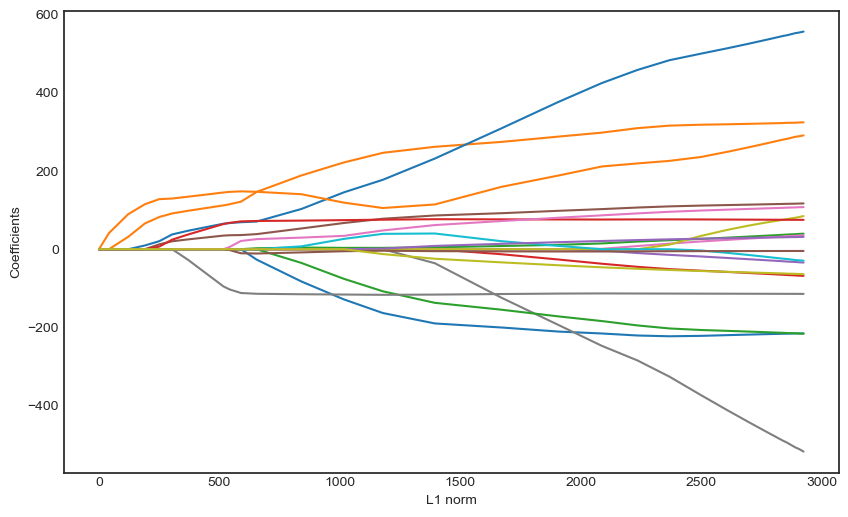

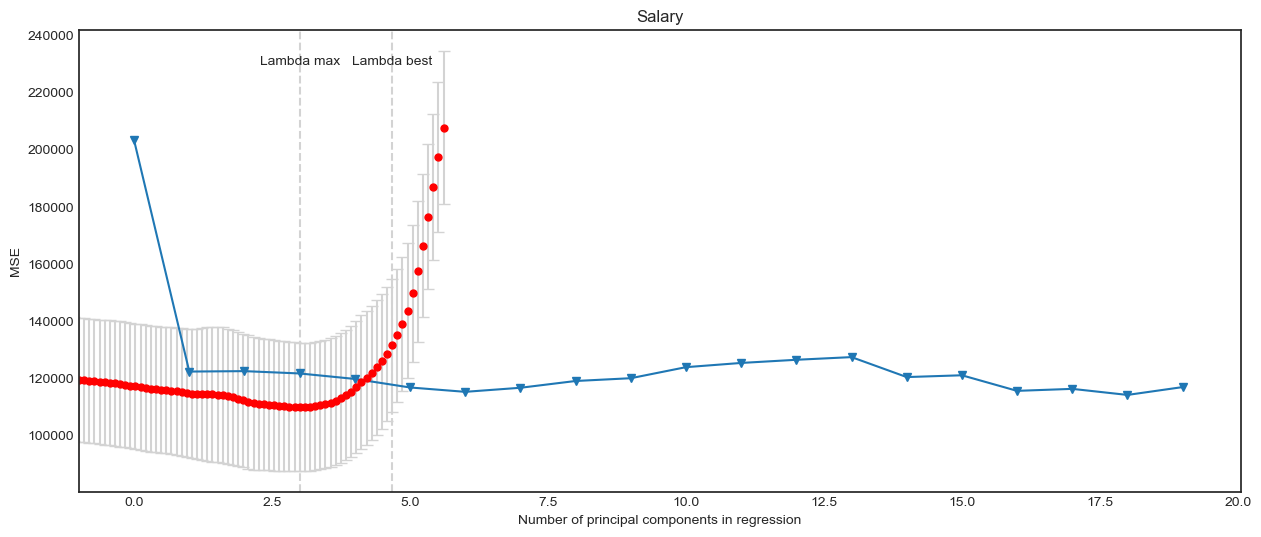

In [162]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression # 10-fold CV, with shuffle
n = len(X_reduced)
kf_10 = KFold(n_splits=10, shuffle=True, random_state=1)

regr = LinearRegression()
mse = []

# Calculate MSE with only the intercept (no principal components in regression)
score = -1*cross_val_score(regr, np.ones((n,1)), y.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()    
mse.append(score)

# Calculate MSE using CV for the 19 principle components, adding one component at the time.
for i in np.arange(1, 20):
    score = -1*cross_val_score(regr, X_reduced[:,:i], y.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(score)
    
plt.plot(mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)
plt.show()

The above plot indicates that the lowest training MSE is reached when doing regression on 18 components.

In [163]:
regr_test = LinearRegression()
regr_test.fit(X_reduced, y)
regr_test.coef_

array([ 106.36859204,   21.60350456,   24.2942534 ,  -36.9858579 ,
        -58.41402748,   62.20632652,   24.63862038,  -15.82817701,
         29.57680773,   99.64801199,   30.11209105,  -20.99269291,
        -72.40210574, -276.68551696,  -74.17098665,  422.72580227,
        347.05662353, -561.59691587,  -83.25441536])

#### Fitting PCA with training data

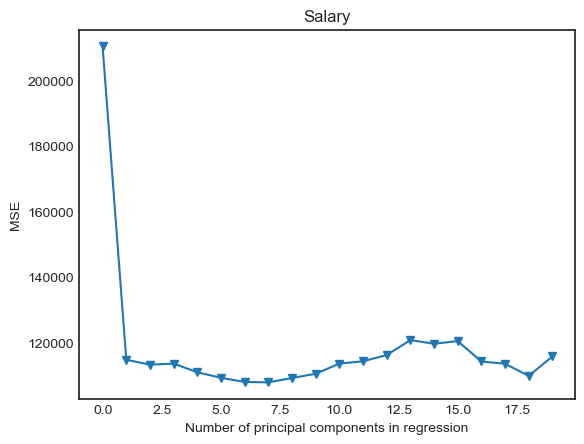

In [165]:
pca2 = PCA()
X_reduced_train = pca2.fit_transform(scale(X_train))
n = len(X_reduced_train)

# 10-fold CV, with shuffle
# kf_10 = KFold(n_splits=10, shuffle=False, random_state=1)
kf_10 = KFold(n_splits=10, shuffle=False)

mse = []

# Calculate MSE with only the intercept (no principal components in regression)
score = -1*cross_val_score(regr, np.ones((n,1)), y_train, cv=kf_10, scoring='neg_mean_squared_error').mean()    
mse.append(score)

# Calculate MSE using CV for the 19 principle components, adding one component at the time.
for i in np.arange(1, 20):
    score = -1*cross_val_score(regr, X_reduced_train[:,:i], y_train, cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(score)

plt.plot(np.array(mse), '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)
plt.show()


The above plot indicates that the lowest training MSE is reached when doing regression on 6 components.

#### Transform test data with PCA loadings and fit regression on 6 principal components

In [166]:
X_reduced_test = pca2.transform(scale(X_test))[:,:7]

# Train regression model on training data 
regr = LinearRegression()
regr.fit(X_reduced_train[:,:7], y_train)

# Prediction with test data
pred = regr.predict(X_reduced_test)
mean_squared_error(y_test, pred)

156278.23920071337

### 6.7.2 Partial Least Squares

Scikit-learn PLSRegression gives same results as the pls package in R when using 'method='oscorespls'. In the LAB excercise, the standard method is used which is 'kernelpls'. 

When doing a slightly different fitting in R, the result is close to the one obtained using scikit-learn.

    pls.fit=plsr(Salary~., data=Hitters, subset=train, scale=TRUE, validation="CV", method='oscorespls')
    validationplot(pls.fit,val.type="MSEP", intercept = FALSE)
   
See documentation:
http://scikit-learn.org/dev/modules/generated/sklearn.cross_decomposition.PLSRegression.html#sklearn.cross_decomposition.PLSRegression

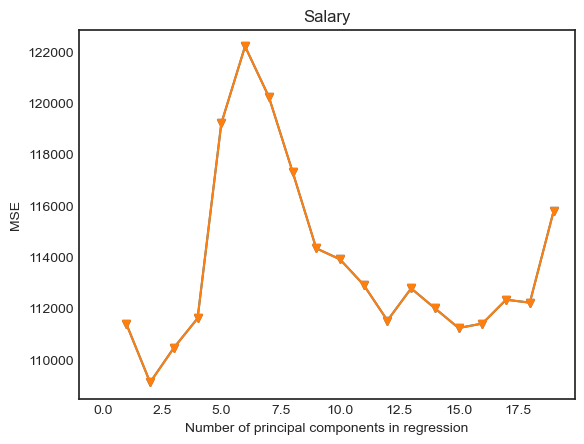

In [170]:
from sklearn.cross_decomposition import PLSRegression
n = len(X_train)

# 10-fold CV, with shuffle
kf_10 = KFold(n_splits=10, shuffle=False)

mse = []

for i in np.arange(1, 20):
    pls = PLSRegression(n_components=i)
    score = cross_val_score(pls, scale(X_train), y_train, cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(-score)

plt.plot(np.arange(1, 20), np.array(mse), '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)
plt.show()

In [171]:
pls = PLSRegression(n_components=2)
pls.fit(scale(X_train), y_train)

mean_squared_error(y_test, pls.predict(scale(X_test)))

160281.09295514197

## CRIME DATASET

In [172]:
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

In [176]:
df = np.loadtxt('Data/crime.txt', delimiter='\t', skiprows=1)
print(df)

[[1.51000e+01 1.00000e+00 9.10000e+00 5.80000e+00 5.60000e+00 5.10000e-01
  9.50000e+01 3.30000e+01 3.01000e+01 1.08000e-01 4.10000e+00 3.94000e+03
  2.61000e+01 8.46020e-02 2.62011e+01 7.91000e+02]
 [1.43000e+01 0.00000e+00 1.13000e+01 1.03000e+01 9.50000e+00 5.83000e-01
  1.01200e+02 1.30000e+01 1.02000e+01 9.60000e-02 3.60000e+00 5.57000e+03
  1.94000e+01 2.95990e-02 2.52999e+01 1.63500e+03]
 [1.42000e+01 1.00000e+00 8.90000e+00 4.50000e+00 4.40000e+00 5.33000e-01
  9.69000e+01 1.80000e+01 2.19000e+01 9.40000e-02 3.30000e+00 3.18000e+03
  2.50000e+01 8.34010e-02 2.43006e+01 5.78000e+02]
 [1.36000e+01 0.00000e+00 1.21000e+01 1.49000e+01 1.41000e+01 5.77000e-01
  9.94000e+01 1.57000e+02 8.00000e+00 1.02000e-01 3.90000e+00 6.73000e+03
  1.67000e+01 1.58010e-02 2.99012e+01 1.96900e+03]
 [1.41000e+01 0.00000e+00 1.21000e+01 1.09000e+01 1.01000e+01 5.91000e-01
  9.85000e+01 1.80000e+01 3.00000e+00 9.10000e-02 2.00000e+00 5.78000e+03
  1.74000e+01 4.13990e-02 2.12998e+01 1.23400e+03]
 [1.2

In [177]:
X=df[:,1:]
y=df[:,0]

In [178]:
X.shape

(47, 15)

In [179]:
y.shape

(47,)

In [180]:
#alpha_ridge=np.arange(0,50,0.5)
#alpha_ridge = [0,1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1e-1,1, 5, 10, 20]
alpha_ridge=np.logspace(np.log10(1e-4), np.log10(35), 100)

In [181]:
X_train = pd.read_csv('Data/Hitters_X_train.csv', index_col=0).values
y_train = pd.read_csv('Data/Hitters_y_train.csv', index_col=0).values
X_test = pd.read_csv('Data/Hitters_X_test.csv', index_col=0).values
y_test = pd.read_csv('Data/Hitters_y_test.csv', index_col=0).values

In [182]:
X=X_train
y=y_train

### Ridge

In [183]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [184]:
def Plot_Ridgle_lambda(X,y):
    loss=[]
    for lam in alpha_ridge:
        clf = Ridge(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        e=np.mean((y-y_pred)**2)+lam*(clf.intercept_**2+np.sum(clf.coef_**2))
        loss.append(e)
    plt.plot(loss)
    plt.show()

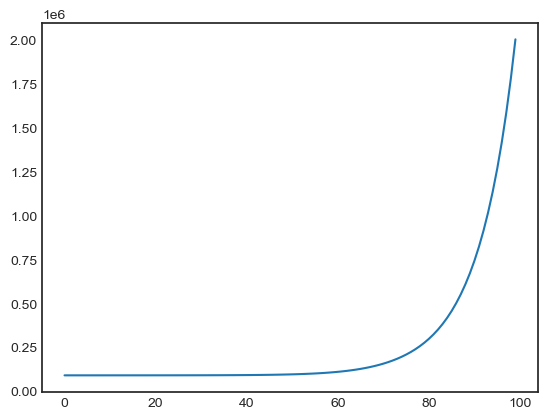

In [185]:
%matplotlib inline
Plot_Ridgle_lambda(X_train,y_train)

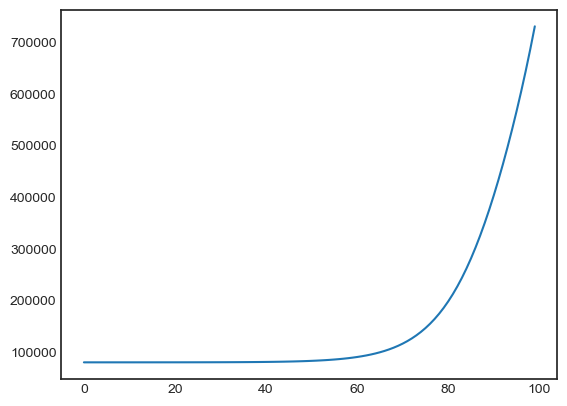

In [186]:
Plot_Ridgle_lambda(X_test,y_test)

### Lasso

In [187]:
from sklearn.linear_model import Lasso

In [188]:
def Plot_Lasso_lambda(X,y):
    loss=[]
    for lam in alpha_ridge:
        clf = Lasso(alpha=lam**2)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        loss.append(np.mean((y-y_pred)**2))
    plt.plot(loss)
    plt.show()

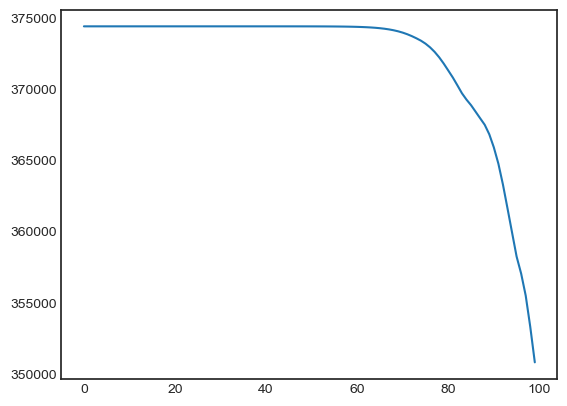

In [189]:
Plot_Lasso_lambda(X_train,y_train)

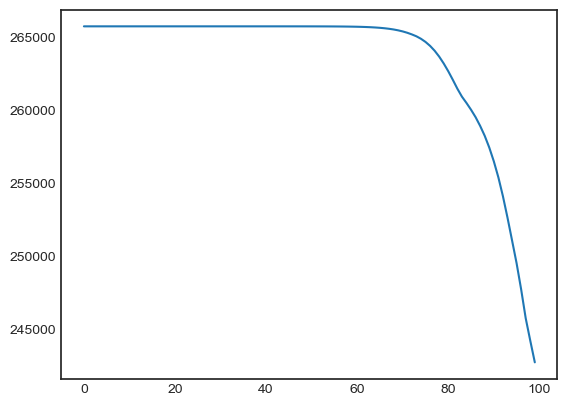

In [190]:
Plot_Lasso_lambda(X_test,y_test)

## import glmnet

In [198]:
#import glmnet
import glmnet as gln


In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [196]:
boston = load_diabetes()
diabetes = load_diabetes()
X, y = boston['data'], boston['target']
# X, y = diabetes['data'], diabetes['target']

lambdas = np.logspace(np.log10(1e-4), np.log10(35), 100)

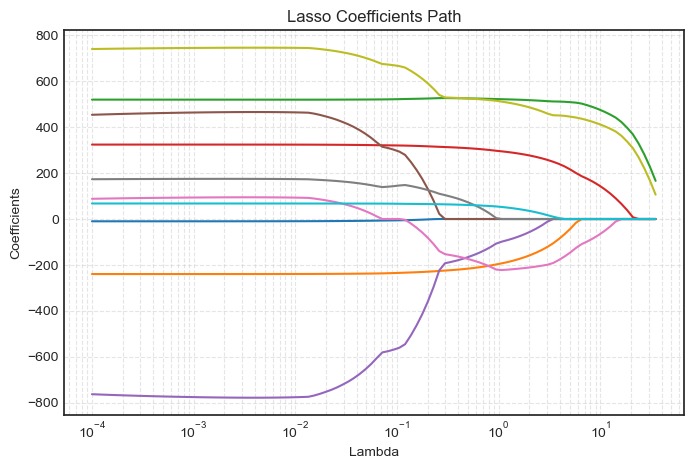

In [200]:
%matplotlib inline

# 1. Sử dụng gln.ElasticNet(alpha=1) đại diện cho Lasso
lasso = gln.ElasticNet(alpha=1, lambda_path=lambdas)
lasso.fit(X, y)
yhat = lasso.predict(X)

# 2. Vẽ đồ thị sự thay đổi của các hệ số theo Lambda
plt.figure(figsize=(8, 5))
plt.plot(lasso.lambda_path_, lasso.coef_path_.T)
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficients Path')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


In [203]:
enet = gln.ElasticNet(lambda_path=lambdas)
enet.fit(X, y)
yhat = enet.predict(X)

In [204]:
import glmnet as gln

In [205]:
df=pd.read_csv('Data/Credit.csv').drop(['Unnamed: 0'],axis=1)
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [206]:
df1=df[['Income','Limit','Rating','Student']]

In [207]:
dummies = pd.get_dummies(df[['Gender', 'Student', 'Married','Ethnicity']])

In [208]:
dummies

,Gender_Female,Gender_Male,Student_No,Student_Yes,Married_No,Married_Yes,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian
0,False,True,True,False,False,True,False,False,True
1,True,False,False,True,False,True,False,True,False
2,False,True,True,False,True,False,False,True,False
3,True,False,True,False,True,False,False,True,False
4,False,True,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
395,False,True,True,False,False,True,False,False,True
396,False,True,True,False,True,False,True,False,False
397,True,False,True,False,False,True,False,False,True
398,False,True,True,False,False,True,False,False,True


In [209]:
X_ = df.drop(['Balance','Gender', 'Student', 'Married','Ethnicity'], axis = 1).astype('float64')

In [210]:
# Define the feature set X.
df2 = pd.concat([X_, dummies[['Student_Yes']]], axis = 1)

In [211]:
X=df2.values

In [212]:
y=df.Balance

In [213]:
X.shape,y.shape

((400, 7), (400,))

In [214]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error


In [215]:
X=X_train
y=y_train

In [216]:
X=X_test
y=y_test

In [217]:
X=np.random.rand(50,5)

In [218]:
y=X[:,0]+2*X[:,1]+0.1*np.random.rand(50)

In [219]:
X.shape,y.shape

((50, 5), (50,))

In [220]:
model1 = LinearRegression()
model1.fit(X, y)
model1.score(X,y)

0.9985828968324131

In [221]:
y_pred = model1.predict(X)
mean_squared_error(y_pred,y)

0.0005995395864134944

In [222]:
model2 = Ridge(alpha=10.0)
model2.fit(X, y)
model2.score(X,y)

0.5033725691972123

In [223]:
y_pred = model2.predict(X)
mean_squared_error(y_pred,y)

0.2101101820075108

In [224]:
model3 = Lasso(alpha=0.1)
model3.fit(X, y)
model3.score(X,y)

0.5000554715751887

In [225]:
y_pred = model3.predict(X)
mean_squared_error(y_pred,y)

0.21151355995619447

In [226]:
lambdas = np.logspace(np.log10(1e-4), np.log10(100), 50)

In [227]:
lambdas = np.logspace(np.log10(1e-5), np.log10(1), 50)
def Plot_Lasso_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Lasso(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        #loss.append(mean_squared_error(y_pred,y))
        loss.append(clf.coef_)
    plt.plot(loss)
    plt.title('Hệ số hồi quy Lasso')
    plt.xlabel('log(lambda)')
    plt.ylabel('Hệ số hồi quy')
    plt.show()

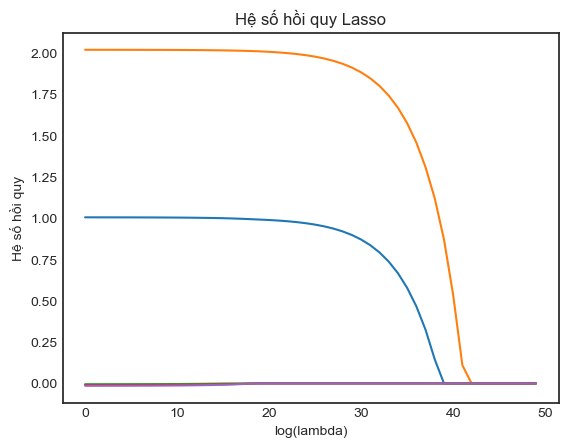

In [228]:
Plot_Lasso_lambda(X,y)

In [229]:
lambdas = np.logspace(np.log10(1e-5), np.log10(1), 50)
def Plot_Lasso_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Lasso(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        #loss.append(mean_squared_error(y_pred,y))
        loss.append(clf.coef_[:2])
    plt.plot(loss)
    plt.title('Hệ số hồi quy Lasso')
    plt.xlabel('log(lambda)')
    plt.ylabel('Hệ số hồi quy')
    plt.show()

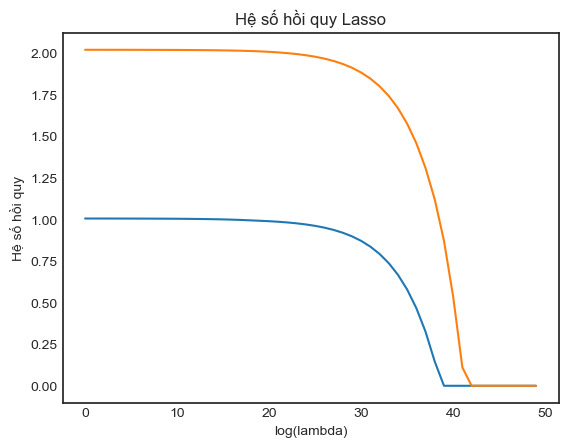

In [230]:
Plot_Lasso_lambda(X,y)

In [231]:
lambdas = np.logspace(np.log10(1e-5), np.log10(1000), 50)
def Plot_Ridge_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Ridge(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        #loss.append(mean_squared_error(y_pred,y))
        #loss.append(clf.coef_[2:])
        loss.append(clf.coef_)
    plt.plot(loss)
    plt.title('Hệ số hồi quy Ridge')
    plt.xlabel('log(lambda)')
    plt.ylabel('Hệ số hồi quy')
    plt.show()

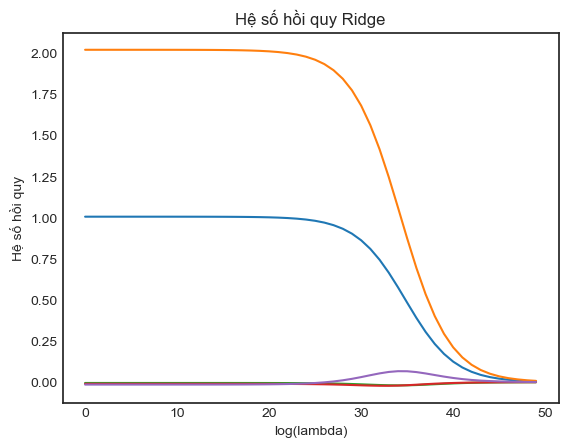

In [232]:
Plot_Ridge_lambda(X,y)

In [233]:
lambdas = np.logspace(np.log10(1e-5), np.log10(1000), 50)
def Plot_Ridge_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Ridge(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        #loss.append(mean_squared_error(y_pred,y))
        loss.append(clf.coef_[:2])
    plt.plot(loss)
    plt.title('Hệ số hồi quy Ridge')
    plt.xlabel('log(lambda)')
    plt.ylabel('Hệ số hồi quy')
    plt.show()

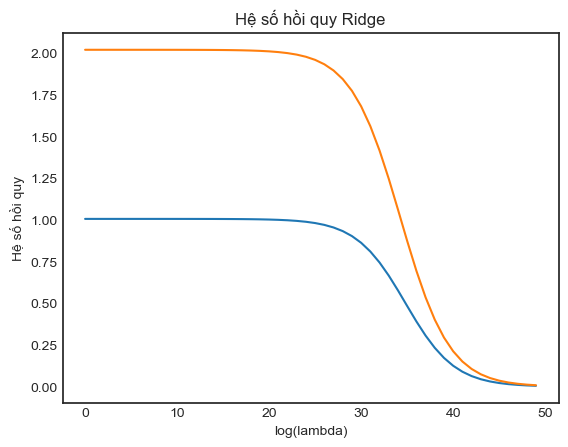

In [234]:
Plot_Ridge_lambda(X,y)

In [235]:
lambdas = np.logspace(np.log10(1e-4), np.log10(10000), 50)
def Plot_Lasso_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Lasso(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        loss.append(mean_squared_error(y_pred,y))#+lam*np.sum(np.abs(clf.coef_)))
        #loss.append(clf.coef_[2:])
    plt.plot(loss)
    plt.title('Hệ số hồi quy Lasso')
    plt.xlabel('log(lambda)')
    plt.ylabel('MSE')
    plt.show()

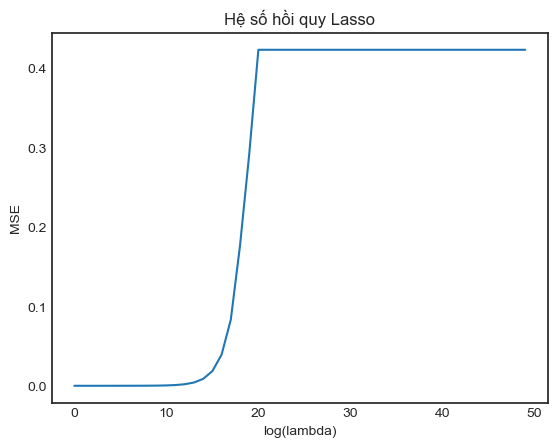

In [236]:
Plot_Lasso_lambda(X,y)

In [237]:
lambdas = np.logspace(np.log10(1e-5), np.log10(1000), 50)
def Plot_Ridge_lambda(X,y):
    loss=[]
    for lam in lambdas:
        clf = Ridge(alpha=lam)
        clf.fit(X, y)
        y_pred=clf.predict(X)
        loss.append(mean_squared_error(y_pred,y))#+lam*np.sum(clf.coef_**2))
        #loss.append(clf.coef_[2:])
        #loss.append(clf.coef_)
    plt.plot(loss)
    plt.title('Hệ số hồi quy Ridge')
    plt.xlabel('log(lambda)')
    plt.ylabel('MSE')
    plt.show()

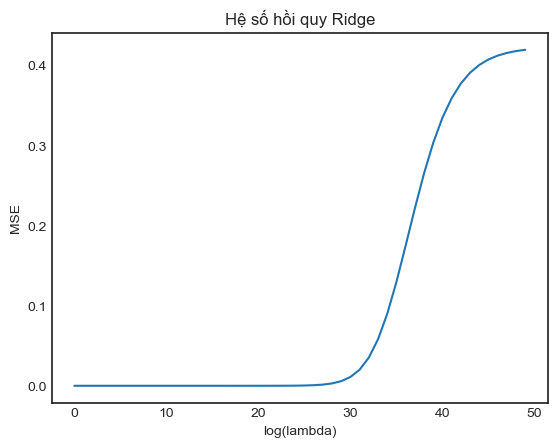

In [238]:
Plot_Ridge_lambda(X,y)

In [239]:
from sklearn.linear_model import RidgeCV

In [240]:
loss=[]
model = RidgeCV(alphas=lambdas, scoring='neg_mean_squared_error',cv=5)
model.fit(X, y)
y_pred=model.predict(X)
print(mean_squared_error(y_pred,y))


0.0006035483941163955
